<a href="https://colab.research.google.com/github/dbansal02/SciML_ME697_Project/blob/main/PIFT_SpringMassDamper_inprogress.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PIFT Applied to a Spring-Mass-Damper System

## Physics-Informed Information Field Theory — Forward Problem

This notebook applies the same PIFT methodology from Example 1 (heat equation) to an **ordinary differential equation**: the spring-mass-damper system.

### Governing Equation

The equation of motion is:

$$m\ddot{x} + c\dot{x} + kx = f(t), \quad t \in [0, T]$$

with initial conditions:

$$x(0) = x_0, \quad \dot{x}(0) = v_0$$

**Parameters used here:**
- $m = 1$ kg, $k = 4$ N/m, $c = 0.4$ N·s/m
- Damping ratio: $\zeta = c/(2\sqrt{mk}) = 0.1$ (underdamped)
- Natural frequency: $\omega_n = \sqrt{k/m} = 2$ rad/s
- Initial conditions: $x_0 = 1.0$ m, $v_0 = 0.0$ m/s
- Time horizon: $T = 10$ s, free response ($f(t) = 0$)

### Key Idea

Instead of integrating the ODE, we **minimize a physics-informed energy functional** whose unique minimizer is the true solution. The functional is the integrated squared ODE residual:

$$U[\phi] = \int_0^T \left[m\ddot{x}(t;\theta) + c\dot{x}(t;\theta) + kx(t;\theta) - f(t)\right]^2 dt$$

This equals zero only when $x(t;\theta)$ satisfies the ODE exactly. We parameterize $x(t;\theta)$ with Fourier basis functions in a way that **automatically satisfies the initial conditions**, then minimize $U$ over $\theta$ using L-BFGS-B with JAX-computed gradients.

## 1. Imports and Setup

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Enable 64-bit floats for numerical stability
jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")

JAX version: 0.7.2
Devices: [CpuDevice(id=0)]


## 2. System Parameters and Exact Solution

For an underdamped system with $\zeta < 1$ and zero forcing, the exact closed-form solution is:

$$x(t) = e^{-\zeta\omega_n t}\left[x_0 \cos(\omega_d t) + \frac{v_0 + \zeta\omega_n x_0}{\omega_d}\sin(\omega_d t)\right]$$

where $\omega_d = \omega_n\sqrt{1-\zeta^2}$ is the damped natural frequency.

Natural frequency  ω_n = 2.0000 rad/s
Damping ratio      ζ   = 0.1000
Damped frequency   ω_d = 1.9900 rad/s
System is: underdamped


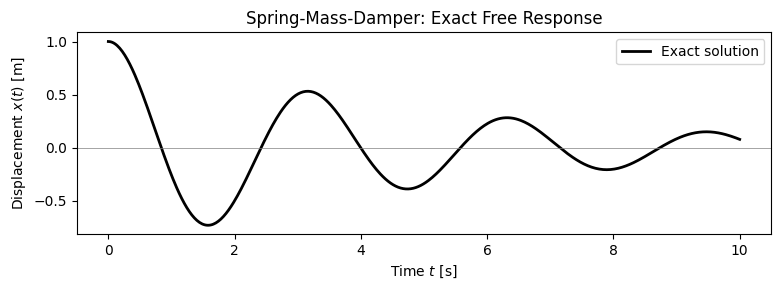

In [ ]:
# System parameters
m  = 1.0   # mass [kg]
k  = 4.0   # spring stiffness [N/m]
c  = 0.4   # damping coefficient [N·s/m]
x0 = 1.0   # initial displacement [m]
v0 = 0.0   # initial velocity [m/s]
T  = 10.0  # time horizon [s]

# Derived quantities
omega_n = np.sqrt(k / m)                   # natural frequency [rad/s]
zeta    = c / (2.0 * np.sqrt(m * k))      # damping ratio [-]
omega_d = omega_n * np.sqrt(1.0 - zeta**2)  # damped natural frequency [rad/s]

print(f"Natural frequency  ω_n = {omega_n:.4f} rad/s")
print(f"Damping ratio      ζ   = {zeta:.4f}")
print(f"Damped frequency   ω_d = {omega_d:.4f} rad/s")
print(f"System is: {'underdamped' if zeta < 1 else 'critically damped' if zeta == 1 else 'overdamped'}")

# Exact analytical solution (free response)
def x_exact(t):
    A = x0
    B = (v0 + zeta * omega_n * x0) / omega_d
    return np.exp(-zeta * omega_n * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))

# Plot the exact solution for reference
t_ref = np.linspace(0, T, 500)
plt.figure(figsize=(8, 3))
plt.plot(t_ref, x_exact(t_ref), 'k-', linewidth=2, label='Exact solution')
plt.axhline(0, color='gray', linewidth=0.5)
plt.xlabel('Time $t$ [s]')
plt.ylabel('Displacement $x(t)$ [m]')
plt.title('Spring-Mass-Damper: Exact Free Response')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Field Parameterization

We parameterize the displacement trajectory as:

$$\hat{x}(t;\theta) = x_0 + v_0 t + t^2 \,\psi(t;\theta)$$

where $\psi(t;\theta)$ is a **truncated Fourier series** in time:

$$\psi(t;\theta) = a_0 + \sum_{j=1}^{K}\left[a_j \cos\!\left(\frac{2\pi j t}{T}\right) + b_j \sin\!\left(\frac{2\pi j t}{T}\right)\right]$$

### Why this works for initial conditions

The $t^2$ prefactor ensures that the first two terms carry all the initial condition information:

$$\hat{x}(0;\theta) = x_0 + 0 + 0 = x_0 $$
$$\dot{\hat{x}}(0;\theta) = v_0 + 0 + 0 = v_0 $$

(Both $2t\psi$ and $t^2\psi'$ vanish at $t=0$.) The Fourier modes are then free to shape the trajectory over $(0, T]$ without disturbing the initial conditions.

In [ ]:
K = 30           # number of Fourier modes
# alpha = 0.2

def unpack_theta(theta):
    beta_raw = theta[0]
    coeffs = theta[1:]
    beta = jnp.exp(beta_raw)   # ensures beta > 0
    return beta, coeffs

# Correct N_theta: 1 (for beta_raw) + 1 (for a0) + K (for a_cos) + K (for b_sin)
N_theta = 2 + 2*K  # total parameters

print(f"Fourier modes K = {K}")
print(f"Total parameters = {N_theta}")

def psi(t, theta):
    """Truncated Fourier series on [0, T]."""
    a0    = theta[0]
    a_cos = theta[1:K+1]
    b_sin = theta[K+1:2*K+1]

    j = jnp.arange(1, K + 1)
    t = jnp.atleast_1d(t)
    t_norm = t / T  # normalize to [0, 1]

    cos_terms = jnp.cos(2.0 * jnp.pi * j[None, :] * t_norm[:, None])
    sin_terms = jnp.sin(2.0 * jnp.pi * j[None, :] * t_norm[:, None])

    return (
        a0
        + jnp.sum(a_cos[None, :] * cos_terms, axis=1)
        + jnp.sum(b_sin[None, :] * sin_terms, axis=1)
    )

# def x_hat(t, theta):
#     t = jnp.atleast_1d(t)
#     return (x0 + v0*t) + t**2 * jnp.exp(-alpha*t) * psi(t, theta)

def x_hat(t, theta):
    beta, coeffs = unpack_theta(theta)
    t = jnp.atleast_1d(t)
    return (x0 + v0*t) + t**2 * jnp.exp(-beta*t) * psi(t, coeffs)

# Verify initial conditions symbolically with zero parameters
theta_zero = jnp.zeros(N_theta)
t_check = jnp.array([0.0, 0.5, 1.0])
print(f"\nWith θ=0: x̂(0) = {x_hat(jnp.array([0.0]), theta_zero)[0]:.4f}  (expected {x0})")

Fourier modes K = 30
Total parameters = 62

With θ=0: x̂(0) = 1.0000  (expected 1.0)


## 4. Time Derivatives via JAX Automatic Differentiation

JAX computes exact derivatives of $\hat{x}(t;\theta)$ with respect to $t$, giving us $\dot{x}$ and $\ddot{x}$ for free.

In [ ]:
def dx_dt(t, theta):
    """First time derivative dx/dt via JAX autodiff."""
    def x_single(t_scalar):
        return x_hat(jnp.array([t_scalar]), theta)[0]
    return jax.vmap(jax.grad(x_single))(jnp.atleast_1d(t))

def d2x_dt2(t, theta):
    """Second time derivative d²x/dt² via JAX autodiff."""
    def x_single(t_scalar):
        return x_hat(jnp.array([t_scalar]), theta)[0]
    return jax.vmap(jax.grad(jax.grad(x_single)))(jnp.atleast_1d(t))

# Quick verification: at t=0 with θ=0, dx/dt should equal v0=0
xdot_at_0 = dx_dt(jnp.array([0.0]), theta_zero)[0]
print(f"ẋ(0) = {xdot_at_0:.6f}  (expected {v0})")

ẋ(0) = 0.000000  (expected 0.0)


## 5. Physics-Informed Energy Functional

The energy functional is the **integrated squared ODE residual**:

$$U(\theta) = \int_0^T \left[m\ddot{x}(t;\theta) + c\dot{x}(t;\theta) + kx(t;\theta) - f(t)\right]^2 dt$$

- $U(\theta) \geq 0$ always.
- $U(\theta) = 0$ if and only if $x(t;\theta)$ satisfies the ODE exactly at every point in $[0,T]$.
- Minimizing $U$ therefore recovers the solution.

The integral is approximated by a Riemann sum on a fine time grid.

> **Contrast with Example 1:** For the heat equation (a linear, self-adjoint BVP), the energy is the variational potential energy whose Euler-Lagrange equation is the PDE. Here we use the squared residual, which is the natural choice for an IVP where no variational principle involving only first derivatives exists for the full (damped) system.

In [ ]:
N_quad = 500  # number of quadrature points
t_grid = jnp.linspace(0.0, T, N_quad)
dt = t_grid[1] - t_grid[0]

def f_forcing(t):
    """External forcing — zero for free response."""
    return jnp.zeros_like(t)

def energy_U(theta):
    """Integrated squared ODE residual: ∫[mẍ + cẋ + kx - f]² dt."""
    t = t_grid
    x_vals    = x_hat(t, theta)
    xdot_vals = dx_dt(t, theta)
    xddot_vals = d2x_dt2(t, theta)

    residual = m * xddot_vals + c * xdot_vals + k * x_vals - f_forcing(t)
    return jnp.sum(residual**2) * dt

# Check energy at zero initialization (should be non-zero — random trajectory)
key = jax.random.PRNGKey(42)
theta_test = 0.01 * jax.random.normal(key, shape=(N_theta,))
print(f"Energy at small random θ: U = {energy_U(theta_test):.6f}")
print(f"(This will be driven toward 0 by the optimizer)")

Energy at small random θ: U = 194.722917
(This will be driven toward 0 by the optimizer)


## 6. Optimization with L-BFGS-B

We compile the energy and its gradient with `jax.jit`, then pass them to `scipy.optimize.minimize` with `method='L-BFGS-B'`.

L-BFGS-B builds a low-rank approximation of the Hessian from gradient history, enabling quasi-Newton steps that converge far faster than plain gradient descent.

In [ ]:
# JIT-compile the energy and its gradient w.r.t. theta
energy_val  = jax.jit(energy_U)
energy_grad = jax.jit(jax.grad(energy_U))

# Small random initialization
theta_init = 0.001 * jax.random.normal(key, shape=(N_theta,))

print("Warming up JIT compilation...")
_ = energy_val(theta_init)   # trigger compilation
_ = energy_grad(theta_init)
print("Done. Running optimization...\n")

loss_history = []

def loss_and_grad(theta_np):
    theta_jax = jnp.array(theta_np)
    val  = float(energy_val(theta_jax))
    grad = np.array(energy_grad(theta_jax), dtype=np.float64)
    loss_history.append(val)
    return val, grad

result = minimize(
    loss_and_grad,
    np.array(theta_init, dtype=np.float64),
    method="L-BFGS-B",
    jac=True,
    options={"maxiter": 5000, "ftol": 1e-15, "gtol": 1e-10},
)

theta_opt = jnp.array(result.x)

print(f"Optimization status  : {result.message}")
print(f"Iterations           : {result.nit}")
print(f"Final energy U(θ*)   : {result.fun:.6e}")

Warming up JIT compilation...
Done. Running optimization...

Optimization status  : STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
Iterations           : 5000
Final energy U(θ*)   : 4.607103e-03


## 7. Results

In [ ]:
# Evaluate optimized solution on a fine grid
t_plot = jnp.linspace(0.0, T, 600)
x_pred  = np.array(x_hat(t_plot, theta_opt))
xdot_pred = np.array(dx_dt(t_plot, theta_opt))
x_ref   = x_exact(np.array(t_plot))

# Pointwise absolute error
abs_err = np.abs(x_pred - x_ref)

print(f"Max pointwise error  : {abs_err.max():.6e} m")
print(f"Mean pointwise error : {abs_err.mean():.6e} m")
print(f"Relative L2 error    : {np.linalg.norm(x_pred - x_ref)/np.linalg.norm(x_ref):.6e}")

Max pointwise error  : 8.332713e-03 m
Mean pointwise error : 2.166467e-03 m
Relative L2 error    : 8.677312e-03


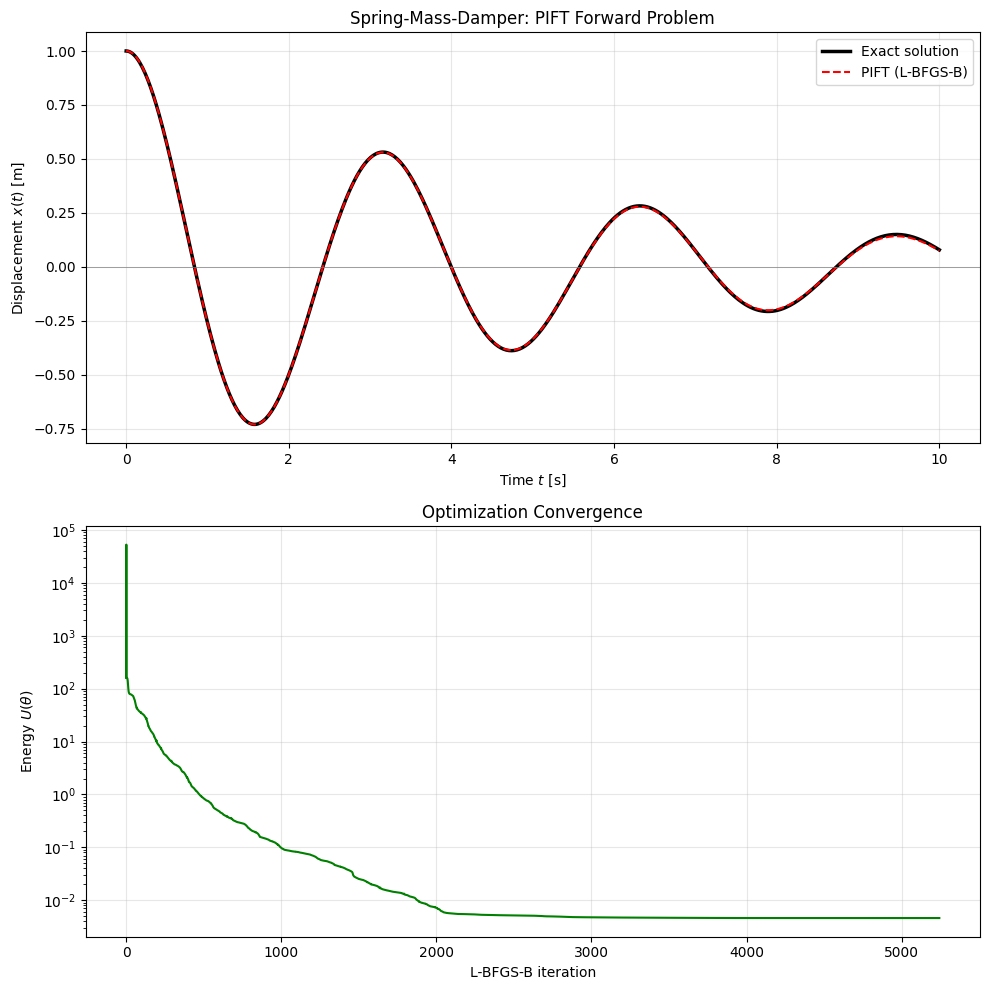

Figure saved.


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

ax = axes[0]
ax.plot(np.array(t_plot), x_ref,  'k-',  linewidth=2.5, label='Exact solution')
ax.plot(np.array(t_plot), x_pred, 'r--', linewidth=1.5, label='PIFT (L-BFGS-B)')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Time $t$ [s]')
ax.set_ylabel('Displacement $x(t)$ [m]')
ax.set_title('Spring-Mass-Damper: PIFT Forward Problem')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(loss_history, 'g-', linewidth=1.5)
ax.set_xlabel('L-BFGS-B iteration')
ax.set_ylabel('Energy $U(\\theta)$')
ax.set_title('Optimization Convergence')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('PIFT_SpringMassDamper_results.png', dpi=150, bbox_inches='tight')
plt.savefig('PIFT_SpringMassDamper_results.svg', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

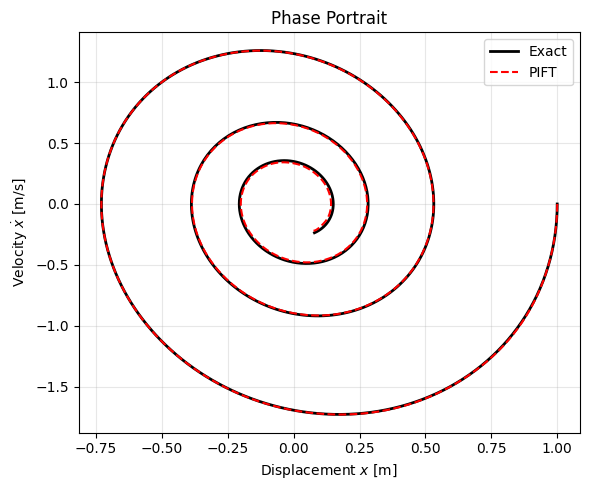

In [ ]:
# Phase portrait: x vs ẋ
xdot_ref = -zeta*omega_n*x_exact(np.array(t_plot)) + np.exp(-zeta*omega_n*np.array(t_plot)) * (
    -x0*omega_d*np.sin(omega_d*np.array(t_plot)) +
    (v0 + zeta*omega_n*x0)*np.cos(omega_d*np.array(t_plot))
)

plt.figure(figsize=(6, 5))
plt.plot(x_ref, xdot_ref,  'k-',  linewidth=2, label='Exact')
plt.plot(x_pred, xdot_pred, 'r--', linewidth=1.5, label='PIFT')
plt.xlabel('Displacement $x$ [m]')
plt.ylabel('Velocity $\\dot{x}$ [m/s]')
plt.title('Phase Portrait')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary

| Quantity | Value |
|---|---|
| Fourier modes $K$ | 30 |
| Parameters $|\theta|$ | 61 |
| Quadrature points | 500 |
| Optimizer | L-BFGS-B |

### Analogy with Example 1 (heat equation)

| Aspect | Heat equation (BVP) | Spring-mass-damper (IVP) |
|---|---|---|
| Domain | $x \in [0,1]$ (space) | $t \in [0,T]$ (time) |
| Field | $\phi(x)$ (temperature) | $x(t)$ (displacement) |
| BCs / ICs | Dirichlet at both ends | $x(0), \dot{x}(0)$ |
| IC enforcement | $(1-x)x$ prefactor | $t^2$ prefactor |
| Energy | $\int\tfrac{1}{2}D(\phi')^2 - \phi q\,dx$ (variational) | $\int [m\ddot{x}+c\dot{x}+kx-f]^2\,dt$ (squared residual) |
| Exact gradients | JAX | JAX |
| Optimizer | L-BFGS-B | L-BFGS-B |

The squared-residual functional is natural for the ODE because the spring-mass-damper is dissipative — there is no potential energy whose Euler-Lagrange equation reproduces the full equation including damping. The squared residual is always non-negative, convex in $\theta$ (for a fixed linear ODE), and reaches its global minimum of zero exactly at the solution.

Running Langevin sampling for beta = 1 ...
  collected 300 valid solution samples
  avg std over time = 6.7314e-06
Running Langevin sampling for beta = 10 ...
  collected 300 valid solution samples
  avg std over time = 1.3619e-02
Running Langevin sampling for beta = 100 ...
  collected 300 valid solution samples
  avg std over time = 3.8205e-02
Running Langevin sampling for beta = 1000 ...
  collected 300 valid solution samples
  avg std over time = 1.6953e-02


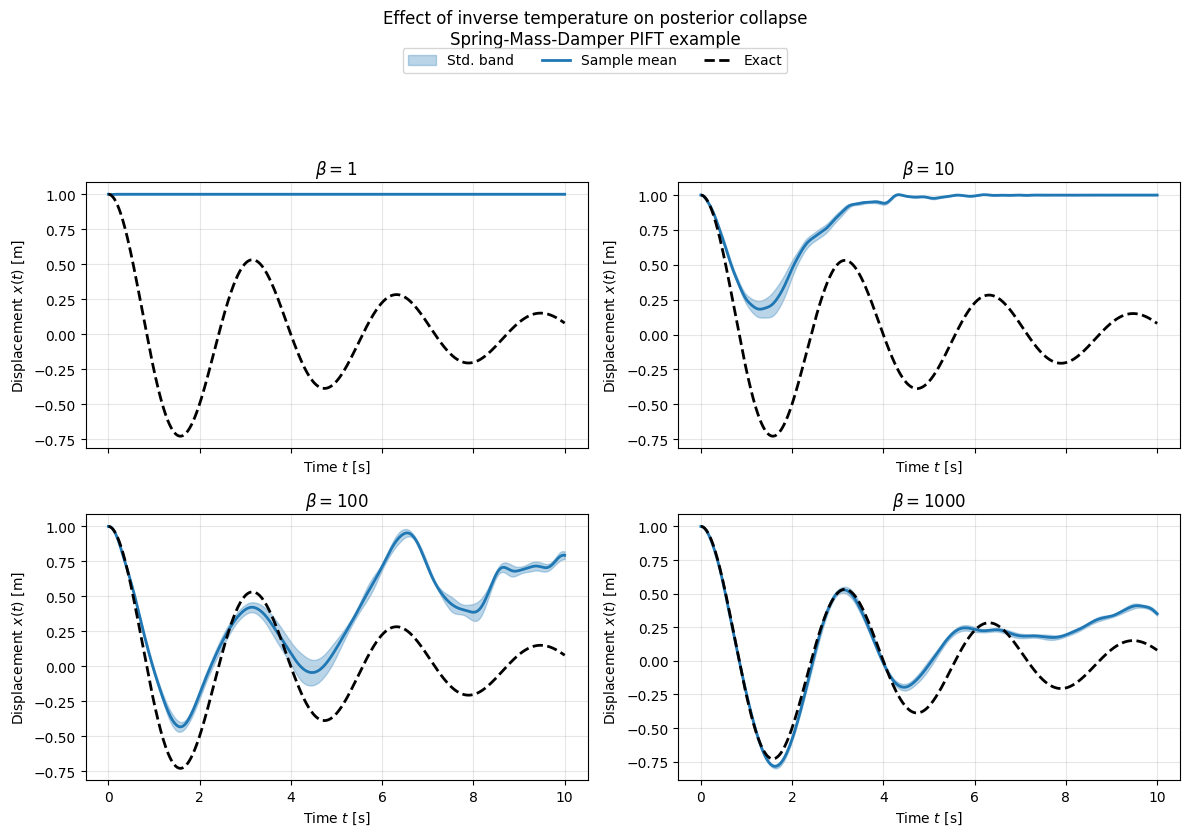

In [ ]:
# ============================================================
# Posterior-style sampling for the spring-mass-damper example
# using unadjusted Langevin dynamics:
#     p(theta) ∝ exp(-beta * U(theta))
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

# ------------------------------------------------------------
# Gradient of the energy (already defined above, but safe here)
# ------------------------------------------------------------
energy_grad = jax.jit(jax.grad(energy_U))

# ------------------------------------------------------------
# Langevin sampler
# ------------------------------------------------------------
def langevin_sample_chain(theta0, beta, n_steps=6000, burn_in=3000, step_size=1e-5, seed=0, max_grad_norm=50.0):
    """
    Unadjusted Langevin algorithm (ULA) for sampling:
        p(theta) ∝ exp(-beta * U(theta))

    Update:
        theta_{k+1} = theta_k - step_size * beta * grad U(theta_k)
                      + sqrt(2 * step_size) * noise

    step_size should be passed as epsilon/beta so the gradient contribution
    (epsilon * gradU) is independent of beta, and the noise term
    sqrt(2*epsilon/beta) naturally shrinks for large beta (sharper posterior).

    Gradient clipping (max_grad_norm) prevents chain divergence.

    Returns:
        samples: array of shape (n_steps - burn_in, N_theta)
    """
    key = jax.random.PRNGKey(seed)
    theta = jnp.array(theta0)
    samples = []

    for i in range(n_steps):
        key, subkey = jax.random.split(key)
        noise = jax.random.normal(subkey, shape=theta.shape)

        gradU = energy_grad(theta)

        # Clip gradient norm to prevent chain divergence
        grad_norm = jnp.linalg.norm(gradU)
        scale = jnp.minimum(1.0, max_grad_norm / (grad_norm + 1e-12))
        gradU = gradU * scale

        theta = theta - step_size * beta * gradU + jnp.sqrt(2.0 * step_size) * noise

        if i >= burn_in:
            samples.append(np.array(theta))

    return np.array(samples)


# ------------------------------------------------------------
# Draw solution curves x(t; theta)
# ------------------------------------------------------------
def sample_solution_curves(theta_samples, t_eval, max_curves=None):
    """
    Evaluate x_hat(t, theta) for each sampled theta.
    Returns array of shape (n_samples, len(t_eval)).
    """
    if max_curves is not None:
        theta_samples = theta_samples[:max_curves]

    curves = []
    for th in theta_samples:
        curves.append(np.array(x_hat(t_eval, jnp.array(th))))
    return np.array(curves)


# ------------------------------------------------------------
# Betas to study
# ------------------------------------------------------------
beta_list = [1, 10, 100, 1000]

# Use your optimized solution as the chain initialization
theta_start = theta_opt

# Evaluation grid
t_eval = t_plot   # uses your already-defined plotting grid
x_exact_eval = x_exact(np.array(t_eval))

# Store results
posterior_results = {}

# ------------------------------------------------------------
# Run Langevin chains for each beta
# ------------------------------------------------------------
for beta in beta_list:
    print(f"Running Langevin sampling for beta = {beta} ...")

    # KEY FIX: use step_size = epsilon / beta so that:
    #   - gradient contribution  = epsilon * gradU  (beta-independent)
    #   - noise term             = sqrt(2*epsilon/beta)  (shrinks with beta)
    # This prevents divergence at large beta and enables exploration at small beta.
    epsilon = 2e-4
    step_size = epsilon / beta

    theta_samples = langevin_sample_chain(
        theta0=theta_start,
        beta=beta,
        n_steps=6000,
        burn_in=3000,
        step_size=step_size,
        seed=beta,
        max_grad_norm=50.0,
    )

    # Evaluate solution curves and filter out any NaN/Inf rows
    x_samples = sample_solution_curves(theta_samples, t_eval, max_curves=300)
    valid = ~np.any(np.isnan(x_samples) | np.isinf(x_samples), axis=1)
    x_samples = x_samples[valid]

    x_mean = np.mean(x_samples, axis=0)
    x_std  = np.std(x_samples, axis=0)

    posterior_results[beta] = {
        "theta_samples": theta_samples,
        "x_samples": x_samples,
        "x_mean": x_mean,
        "x_std": x_std,
    }

    print(f"  collected {x_samples.shape[0]} valid solution samples")
    print(f"  avg std over time = {x_std.mean():.4e}")


# ------------------------------------------------------------
# Plot mean ± std for different beta values
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = axes.ravel()

for ax, beta in zip(axes, beta_list):
    res = posterior_results[beta]
    x_mean = res["x_mean"]
    x_std  = res["x_std"]

    # Draw uncertainty band FIRST so lines appear on top
    ax.fill_between(
        np.array(t_eval),
        x_mean - x_std,
        x_mean + x_std,
        color='tab:blue',
        alpha=0.30,
        label='Std. band',
    )

    # Posterior mean and exact on top of the band
    ax.plot(np.array(t_eval), x_mean, color='tab:blue', linewidth=2.0, label='Sample mean')
    ax.plot(np.array(t_eval), x_exact_eval, 'k--', linewidth=2.0, label='Exact')

    ax.set_title(rf'$\beta = {beta}$')
    ax.set_xlabel(r'Time $t$ [s]')
    ax.set_ylabel(r'Displacement $x(t)$ [m]')
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=True, bbox_to_anchor=(0.5, 1.0))
fig.suptitle(
    'Effect of inverse temperature on posterior collapse\nSpring-Mass-Damper PIFT example',
    y=1.04,
)
# rect leaves room at the top for suptitle + figure legend
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()
